# Banking data Time Series Forecasting

`Topollo Naketsana`

###

#### This project aims to build a predictive model that forecasts each customer’s future transaction activity (next 3 months) by learning behavioral, financial, and demographic patterns from historical banking data.

**Target:** Predict `next_3m_txn_count` for each customer in Test.csv

**Metric:** RMSLE (Root Mean Squared Logarithmic Error)

In [47]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utilsforecast.plotting import plot_series

## 1. Load the data

In [48]:
# Transaction history
txn = pd.read_parquet('transactions_features.parquet')

print(f'Transactions: Shape = {txn.shape} and unique = {txn.UniqueID.nunique():,} customers')
print(f'Date range: {txn.TransactionDate.min()} to {txn.TransactionDate.max()}')

Transactions: Shape = (18017073, 9) and unique = 11,944 customers
Date range: 2012-12-25 00:00:00 to 2015-10-31 00:00:00


#### `The What does 11,944 unique customers imply?`
#### It means: The table is transaction-level data, each row is NOT one customer is one transaction

So, 

$\frac{18017073}{11,944} ​\approx 1508$

on average, each customer has about 1508 transactions

In [49]:
# Financial snapshots
fin = pd.read_parquet('financials_features.parquet')

print(f'Financials: Shape = {fin.shape} and Unique = {fin.UniqueID.nunique():,} customers')

Financials: Shape = (372245, 6) and Unique = 11,377 customers


In [50]:
#fin.head(10) 

In [51]:
txn.head(8)

,UniqueID,AccountID,TransactionDate,TransactionAmount,TransactionTypeDescription,TransactionBatchDescription,StatementBalance,IsDebitCredit,ReversalTypeDescription
0,d7b4459e-41bc-4ab6-98e4-0bfe01a4dfe5,bc348826-aa16-4b71-a2f7-0a78b9cf84cc,2015-03-25,-926.36,Debit Orders & Standing Orders,Not Disclosed / Unknown,-1165.74,Credit,Manual
1,58c224c1-4f38-440f-9c78-b6d5a818839e,1e2e57bc-1ef7-4f0b-8408-861d34065fd5,2015-07-10,-3073.38,Transfers & Payments,System Defined,22420.41,Credit,Manual
2,4e0dfceb-7186-4b71-bb0d-0e39baa31979,51e7813b-a259-43b6-940f-feb0c2d8199e,2015-08-20,45.68,Interest & Investments,System Defined,120793.44,Debit,Sytem
3,ed2ef2a9-0947-45e6-8f7b-023e88a79ca5,724cd259-3e5e-400a-b843-0361a8e3f751,2015-09-05,-8481.62,Transfers & Payments,System Defined,143372.10,Credit,Manual
4,06e8f8b9-f8d4-4ae6-a34c-cfbee38e3b7e,6b5d66ed-caf1-44fd-b649-5774e267dc33,2015-08-28,-936.37,Transfers & Payments,System Defined,59896.47,Credit,Manual
5,b0c8c150-1bdd-401c-bd42-386b4a888ffb,a3e718a6-ae27-4773-a6fe-3c7b36ea5786,2015-10-30,-21.07,Transfers & Payments,System Defined,-12900.18,Credit,Manual
6,6093847d-6d20-48e5-9827-41ebeb24a1de,a50995aa-926a-445f-8cdf-cf782bde107f,2015-09-02,-15.25,Charges & Fees,Credit/Debit Service,-917.58,Credit,Manual
7,888781aa-5575-4969-ac32-7cde4f38ed8c,96da53c0-32ee-4d49-af2a-9f80b60655c7,2015-07-17,-890.90,Withdrawals,System Defined,742.62,Credit,Sytem


In [52]:
txn["Month"] = txn["TransactionDate"].dt.to_period("M")

In [53]:
# info check - for the transactions
txn.info()

<class 'pandas.DataFrame'>
RangeIndex: 18017073 entries, 0 to 18017072
Data columns (total 10 columns):
 #   Column                       Dtype         
---  ------                       -----         
 0   UniqueID                     string        
 1   AccountID                    string        
 2   TransactionDate              datetime64[ns]
 3   TransactionAmount            float64       
 4   TransactionTypeDescription   str           
 5   TransactionBatchDescription  str           
 6   StatementBalance             float64       
 7   IsDebitCredit                str           
 8   ReversalTypeDescription      str           
 9   Month                        period[M]     
dtypes: datetime64[ns](1), float64(2), period[M](1), str(4), string(2)
memory usage: 3.3 GB


In [54]:
txn.describe()

,TransactionDate,TransactionAmount,StatementBalance
count,18017073,1.801707e+07,1.801701e+07
mean,2014-06-10 17:32:19.317158400,-2.965297e+02,1.024209e+05
min,2012-12-25 00:00:00,-1.000000e+06,-1.000000e+06
25%,2013-09-28 00:00:00,-1.345210e+03,4.712340e+03
50%,2014-06-14 00:00:00,-2.858400e+02,3.182312e+04
75%,2015-02-25 00:00:00,-1.600000e+01,1.054964e+05
max,2015-10-31 00:00:00,1.000000e+06,1.000000e+06
std,NaN,5.830508e+04,2.183292e+05


### The information and meaning for each column:
`customer_id` - customer identifier

`TransactionAmount` - Money exchange

`TransactionTypeDescription` - what kind of transaction

`TransactionBatchDescription` - transaction grouping/category

`StatementBalance` - remaining money after transaction

`IsDebitCredit` - debit or credit

`ReversalTypeDescription` - reversed money description


In [55]:
# we can drop acc Id as it is not helpful
txn = txn.drop(columns= 'AccountID') 

In [56]:
# missing values
txn.isna().mean()

UniqueID                       0.000000
TransactionDate                0.000000
TransactionAmount              0.000000
TransactionTypeDescription     0.000000
TransactionBatchDescription    0.000000
StatementBalance               0.000004
IsDebitCredit                  0.000000
ReversalTypeDescription        0.000000
Month                          0.000000
dtype: float64

In [57]:
txn.isna().sum()

UniqueID                        0
TransactionDate                 0
TransactionAmount               0
TransactionTypeDescription      0
TransactionBatchDescription     0
StatementBalance               67
IsDebitCredit                   0
ReversalTypeDescription         0
Month                           0
dtype: int64

In [58]:
txn['StatementBalance']

0            -1165.74
1            22420.41
2           120793.44
3           143372.10
4            59896.47
              ...    
18017068    172315.75
18017069     63075.09
18017070     23654.52
18017071    930474.05
18017072    117802.34
Name: StatementBalance, Length: 18017073, dtype: float64

In [59]:
# Balance alone
balance = txn['StatementBalance'].dropna()

In [60]:
balance.isna().sum()

np.int64(0)

#### *No missing values found from balance*

In [61]:
# check negative statement
(txn['TransactionAmount'] < 0).sum()

np.int64(14641874)

#### *The negative balance signals the debt*

In [62]:
# duplicates
txn.duplicated().sum()

np.int64(391)

In [63]:
txn = txn.drop_duplicates()

In [64]:
txn['IsDebitCredit'].value_counts()

IsDebitCredit
Credit    14641730
Debit      3374952
Name: count, dtype: int64

In [65]:
txn['TransactionTypeDescription'].value_counts()

TransactionTypeDescription
Transfers & Payments              13883454
Charges & Fees                     2341390
Interest & Investments              464061
Other / Unclassified                456997
Debit Orders & Standing Orders      356487
Withdrawals                         302314
Foreign Exchange                     72803
Teller & Branch Transactions         43283
Card Transactions                    36283
Unpaid / Returned Items              28930
Reversals & Adjustments              17549
Deposits                             11655
Account Maintenance                   1476
Name: count, dtype: int64

In [66]:
txn['TransactionBatchDescription'].value_counts().head(20)

TransactionBatchDescription
System Defined              16134560
Other Charges                 641226
Not Disclosed / Unknown       571610
Digital Banking Fees          352670
Transaction Service Fees      234252
Credit/Debit Service           74968
Unallocated                     7388
Other / Unclassified               8
Name: count, dtype: int64

In [67]:
txn['ReversalTypeDescription'].value_counts()

ReversalTypeDescription
Manual            12087557
Sytem              5897110
Not Applicable       32015
Name: count, dtype: int64

In [68]:
# correlation between columns
txn.corr(numeric_only= True)

,TransactionAmount,StatementBalance
TransactionAmount,1.000000,0.080975
StatementBalance,0.080975,1.000000


## 2. Visualization

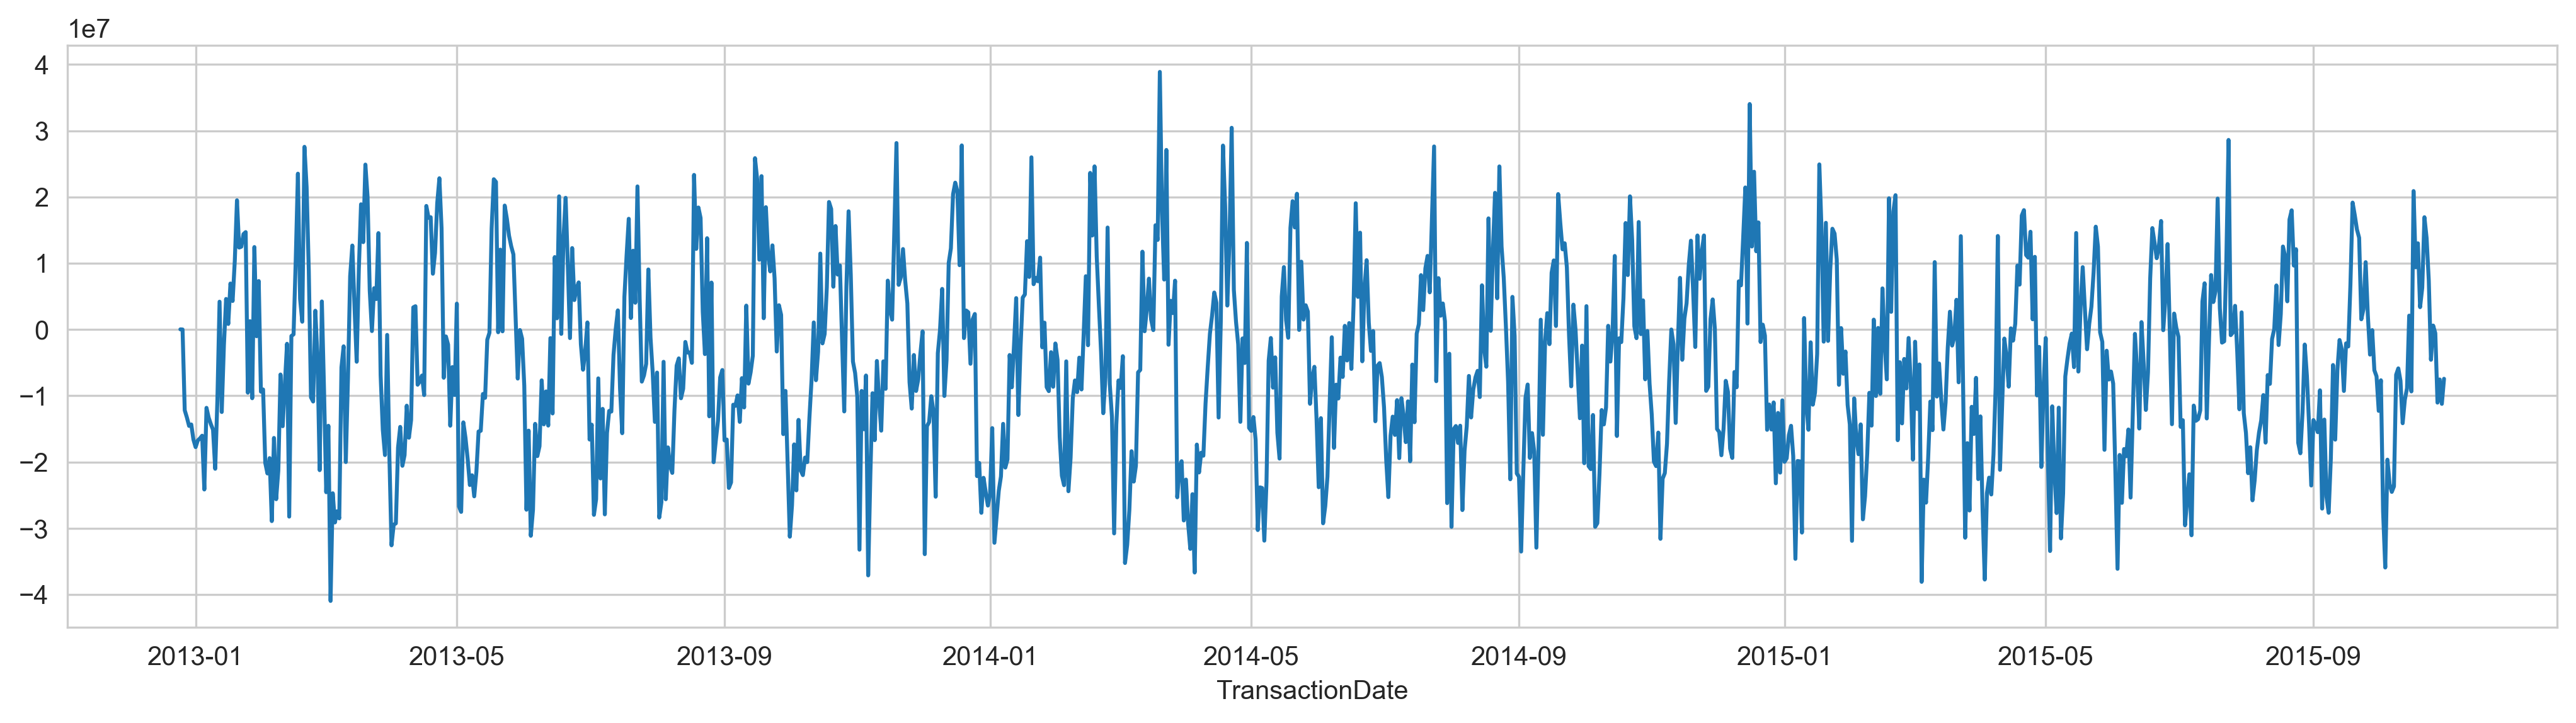

In [69]:
# the behavioral trend
daily_txn = txn.groupby(txn["TransactionDate"].dt.date)["TransactionAmount"].sum()

plt.rcParams.update({'figure.figsize': (17, 4), 'figure.dpi': 300})

sns.lineplot(x= daily_txn.index, y= daily_txn.values)

plt.grid(True)
plt.show()

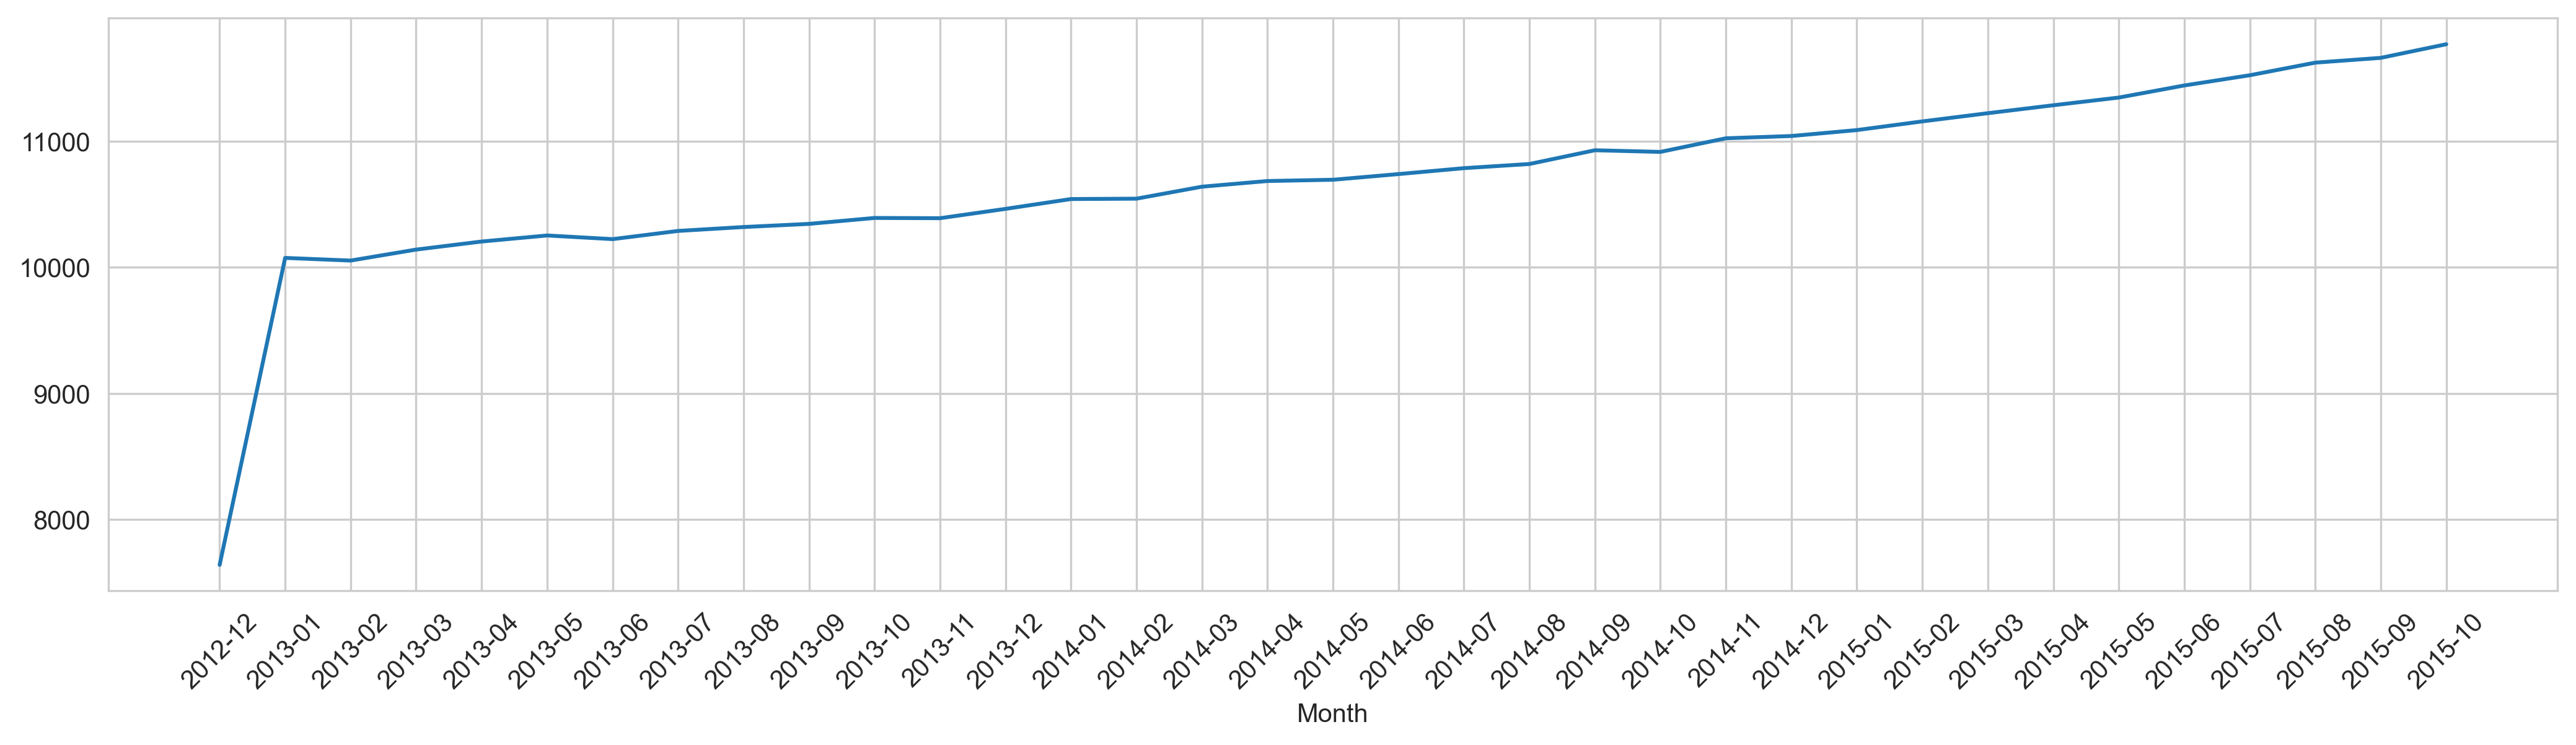

In [70]:
# the behavioral trend
monthly_active = txn.groupby("Month")["UniqueID"].nunique()

plt.rcParams.update({'figure.figsize': (17, 4), 'figure.dpi': 300})

sns.lineplot(x=monthly_active.index.astype(str), y=monthly_active.values)

plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [71]:
sns.set_style('whitegrid')

<Axes: xlabel='StatementBalance', ylabel='Count'>

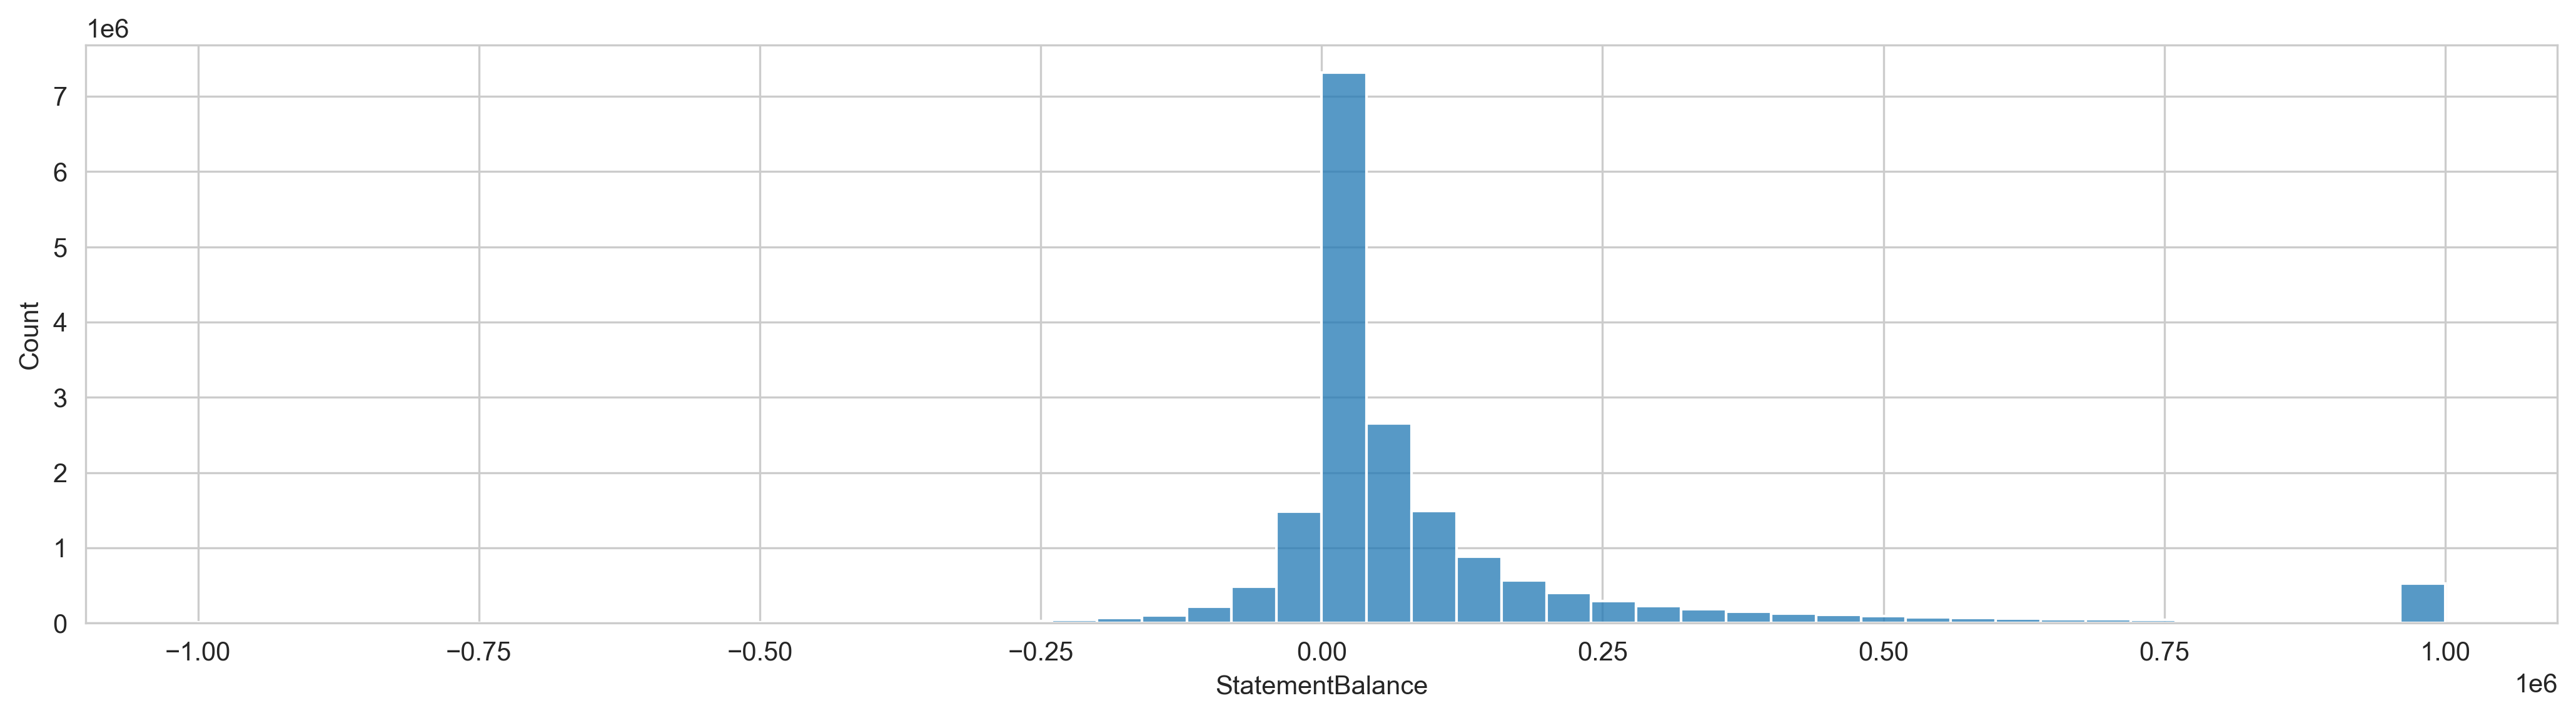

In [72]:
# visual fluctuation of balance
sns.histplot(balance, bins= 50)

<Axes: >

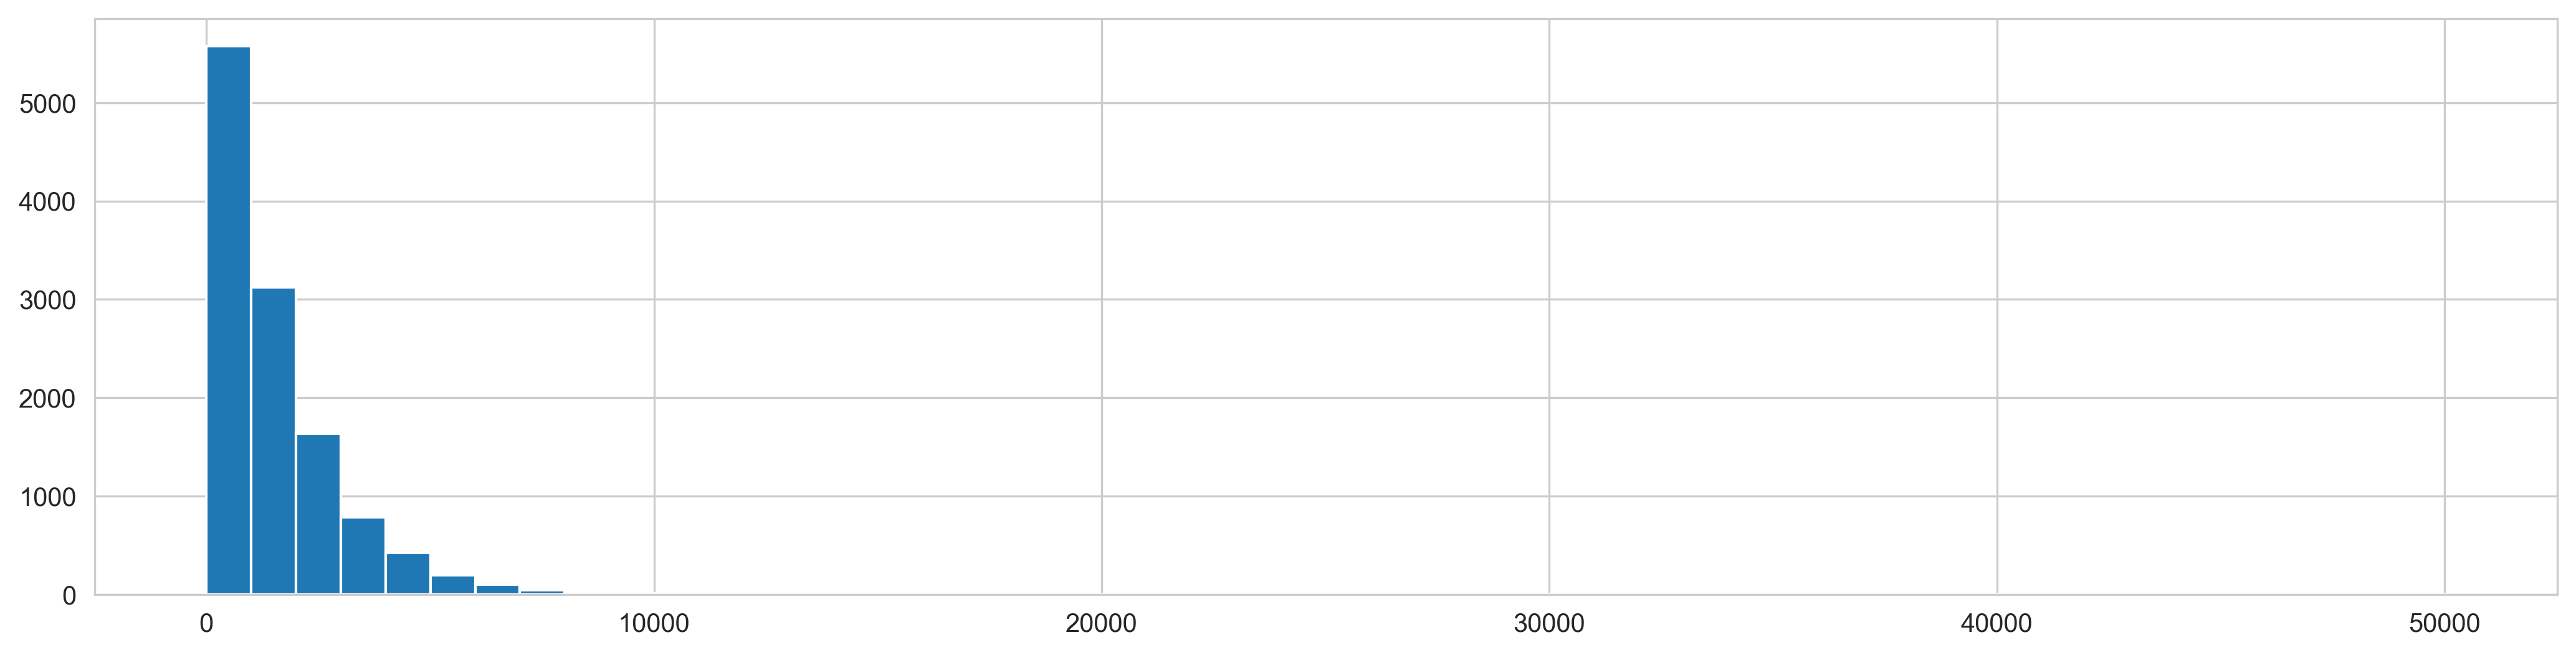

In [73]:
txn.groupby("UniqueID")["TransactionAmount"].count().hist(bins= 50)

<Axes: xlabel='TransactionAmount', ylabel='Count'>

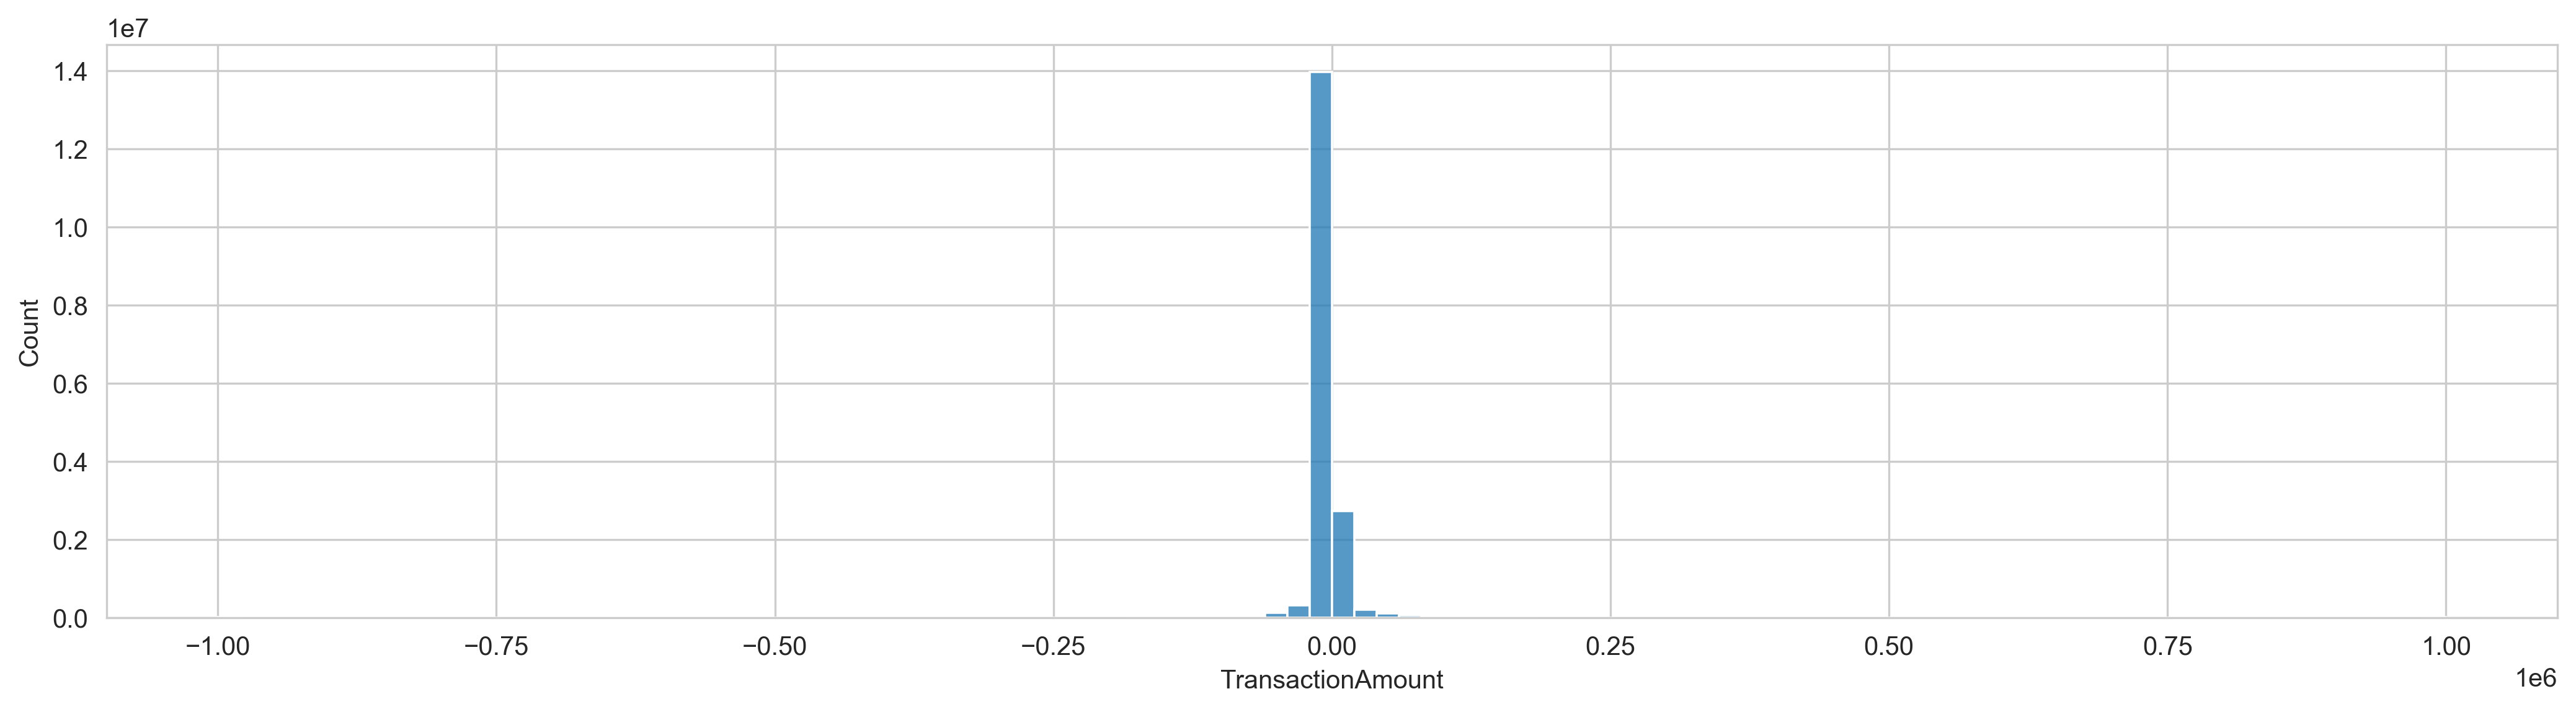

In [74]:
sns.histplot(txn["TransactionAmount"], bins= 100)

<Axes: xlabel='IsDebitCredit'>

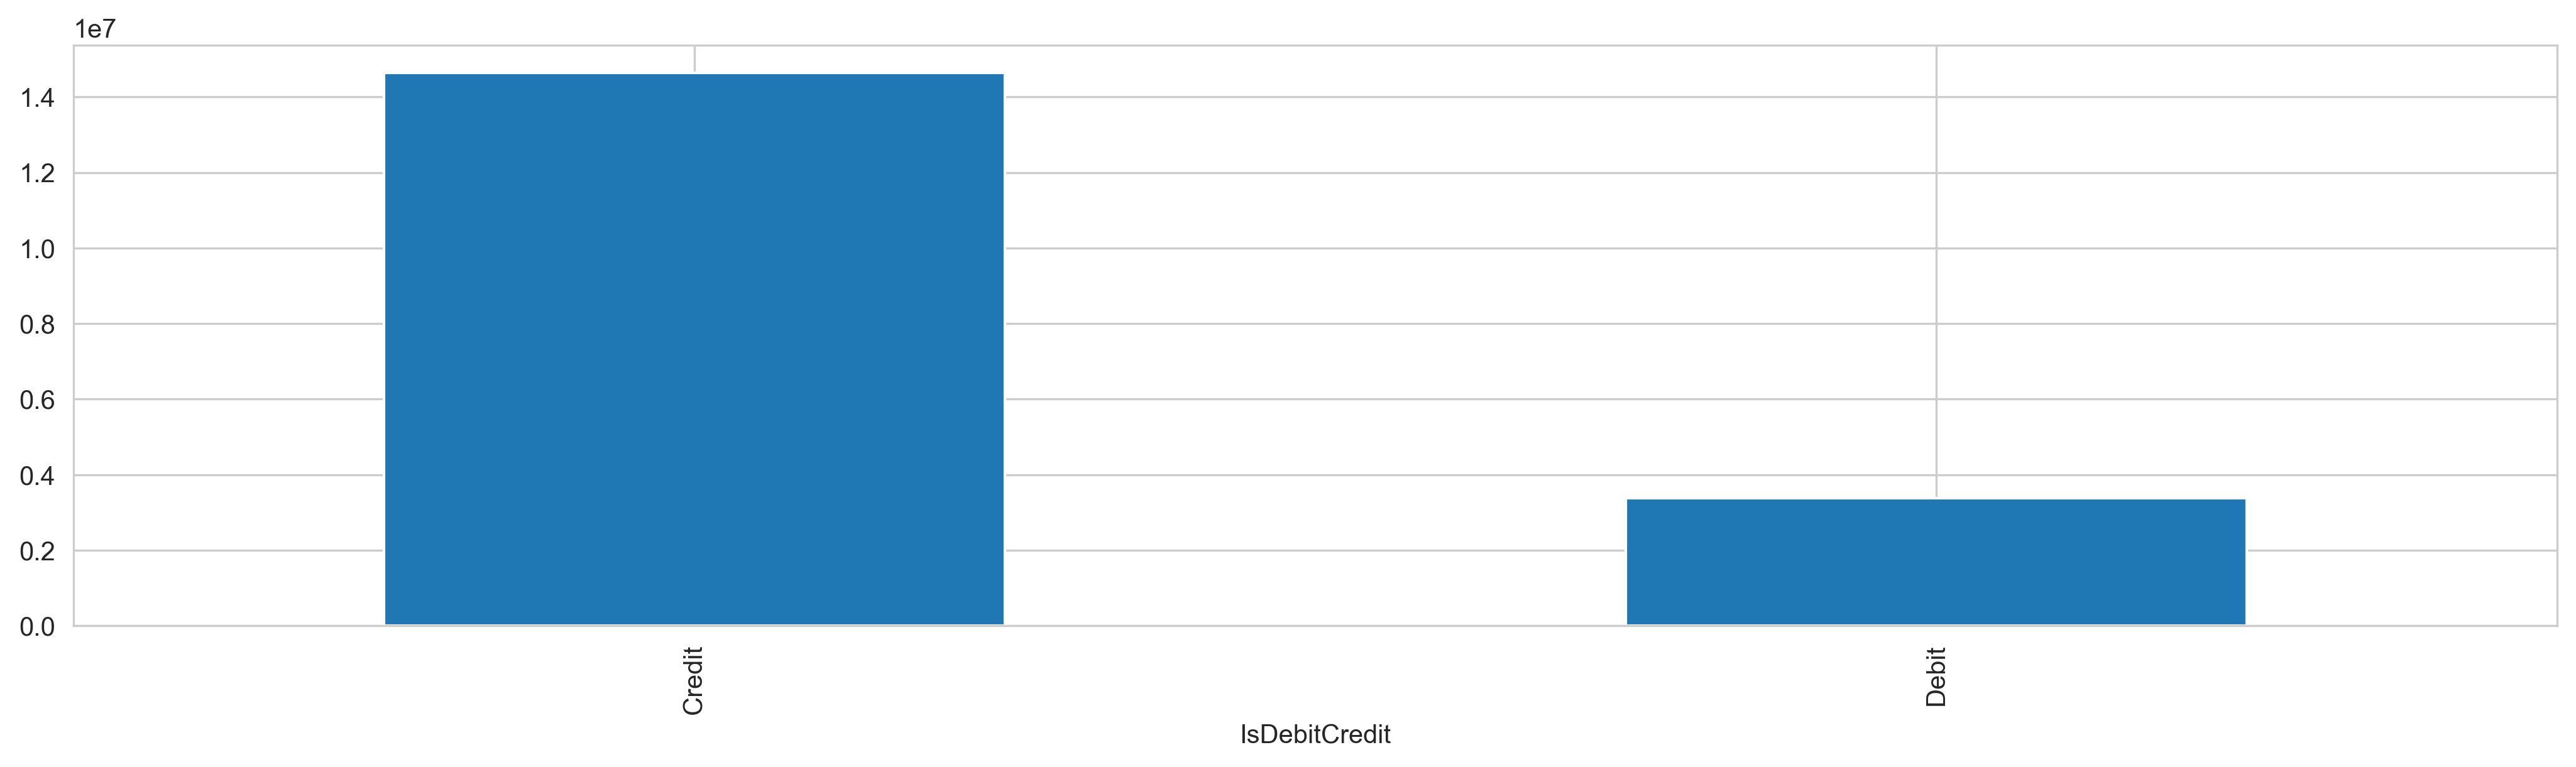

In [75]:
# income vs spending
txn["IsDebitCredit"].value_counts().plot(kind= "bar")

<Axes: xlabel='TransactionTypeDescription'>

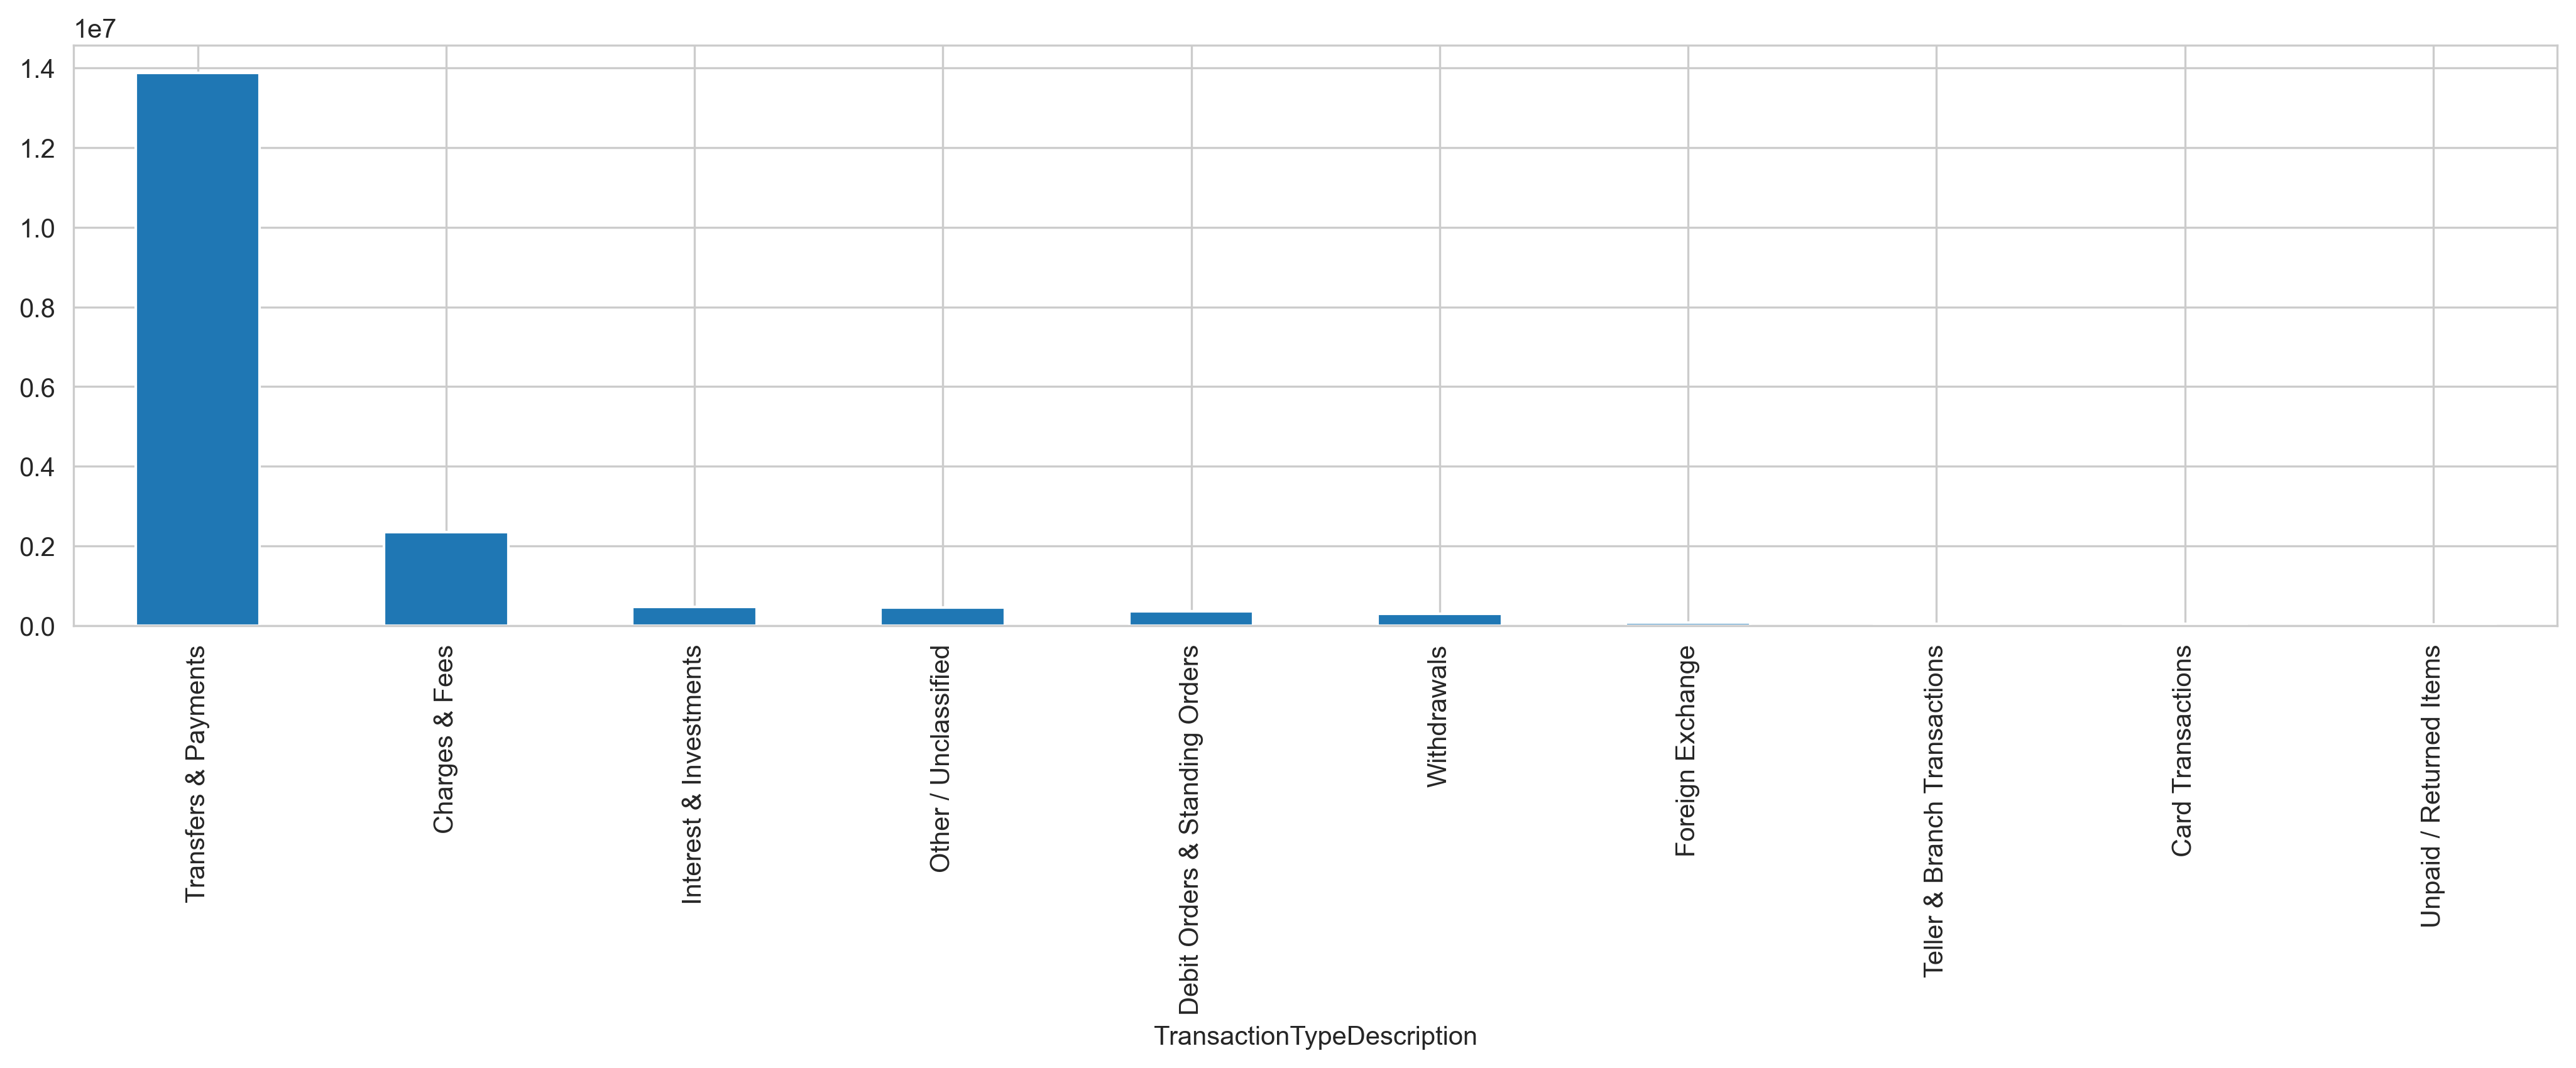

In [76]:
# beetter picture for the cashflow 
txn["TransactionTypeDescription"].value_counts().head(10).plot(kind="bar")

### Their financials?

In [77]:
# info check - for the financials
fin.info()

<class 'pandas.DataFrame'>
RangeIndex: 372245 entries, 0 to 372244
Data columns (total 6 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   UniqueID            372245 non-null  string        
 1   AccountID           318571 non-null  string        
 2   RunDate             372245 non-null  datetime64[ns]
 3   Product             372245 non-null  str           
 4   NetInterestIncome   372242 non-null  float64       
 5   NetInterestRevenue  372123 non-null  float64       
dtypes: datetime64[ns](1), float64(2), str(1), string(2)
memory usage: 45.0 MB


In [78]:
fin.head()

,UniqueID,AccountID,RunDate,Product,NetInterestIncome,NetInterestRevenue
0,dcfae6b7-0c88-40dc-96aa-601df13c075f,5ead03e0-5048-4a9a-8947-f8e9c6482a73,2014-04-29,Transactional,-110.39,638.19
1,a6b8878b-ed4d-4836-8231-804ec1b2e787,<NA>,2015-08-26,Mortgages,448.58,68.42
2,fdaca0bc-ff5c-4622-b25f-423d558cff57,b1bdda89-d050-4de0-9e76-16d251aafe66,2015-08-01,Investments,-385.64,0.00
3,ad75f685-5893-4c7c-b165-5ca9e4da031f,49e6b7b3-c652-4036-a662-15f70e89cd79,2014-02-24,Investments,-89.08,0.00
4,388180f9-73c7-4f2f-a87b-ee9efd02d423,637dcfe7-bb5b-4b34-b451-31479851f487,2015-04-02,Transactional,5.59,581.56


In [79]:
fin.groupby("UniqueID")["NetInterestIncome"].sum()

UniqueID
00038178-a14e-468a-8053-a0edf5cf1b02    149094.88
0006aac7-06d3-4fee-b0f6-11f57b9419e9     -4667.15
00093e2d-9e1e-4061-ad27-a79b8ff9e165     58687.44
0011d60f-a4e2-4333-81fc-2d557a82109b    -37291.18
0016f1e2-64c1-4c65-a668-1dc6bf3b5875       -42.32
                                          ...    
ffe61dd7-7f13-4207-915a-fce8c107605d   -101951.64
ffea919e-6800-412d-b7ef-d3dc5b7c775a      -100.64
fff793d3-7b6e-4a5d-ad1e-2cbe98a21746        -8.74
fff9f2ff-89f3-4684-8247-d8f15d969239     -2945.52
fffc326c-ce49-4aca-828b-1afe3bdbdfbb     -6299.22
Name: NetInterestIncome, Length: 11377, dtype: float64

In [80]:
fin.groupby("UniqueID")["NetInterestIncome"].mean()

UniqueID
00038178-a14e-468a-8053-a0edf5cf1b02    3727.372000
0006aac7-06d3-4fee-b0f6-11f57b9419e9    -222.245238
00093e2d-9e1e-4061-ad27-a79b8ff9e165    1304.165333
0011d60f-a4e2-4333-81fc-2d557a82109b   -1775.770476
0016f1e2-64c1-4c65-a668-1dc6bf3b5875      -2.015238
                                           ...     
ffe61dd7-7f13-4207-915a-fce8c107605d   -4854.840000
ffea919e-6800-412d-b7ef-d3dc5b7c775a     -20.128000
fff793d3-7b6e-4a5d-ad1e-2cbe98a21746      -0.397273
fff9f2ff-89f3-4684-8247-d8f15d969239    -101.569655
fffc326c-ce49-4aca-828b-1afe3bdbdfbb    -299.962857
Name: NetInterestIncome, Length: 11377, dtype: float64

In [81]:
fin.isna().sum()

UniqueID                  0
AccountID             53674
RunDate                   0
Product                   0
NetInterestIncome         3
NetInterestRevenue      122
dtype: int64

In [82]:
fin = fin.drop(columns= 'AccountID')

In [83]:
fin["NetInterestIncome"] = fin["NetInterestIncome"].fillna(0)

In [84]:
fin["NetInterestRevenue"] = fin["NetInterestRevenue"].fillna(
    fin["NetInterestRevenue"].median()
)

In [85]:
fin.isna().sum()

UniqueID              0
RunDate               0
Product               0
NetInterestIncome     0
NetInterestRevenue    0
dtype: int64

In [86]:
fin.info()

<class 'pandas.DataFrame'>
RangeIndex: 372245 entries, 0 to 372244
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   UniqueID            372245 non-null  string        
 1   RunDate             372245 non-null  datetime64[ns]
 2   Product             372245 non-null  str           
 3   NetInterestIncome   372245 non-null  float64       
 4   NetInterestRevenue  372245 non-null  float64       
dtypes: datetime64[ns](1), float64(2), str(1), string(1)
memory usage: 31.2 MB


In [87]:
fin_features = fin.groupby("UniqueID").agg({
    "NetInterestIncome": ["sum", "mean"],
    "NetInterestRevenue": ["sum", "mean"],
    "Product": "nunique"
})

In [88]:
fin_features.head()

NetInterestIncome               \
                                                   sum         mean   
UniqueID                                                              
00038178-a14e-468a-8053-a0edf5cf1b02         149094.88  3727.372000   
0006aac7-06d3-4fee-b0f6-11f57b9419e9          -4667.15  -222.245238   
00093e2d-9e1e-4061-ad27-a79b8ff9e165          58687.44  1304.165333   
0011d60f-a4e2-4333-81fc-2d557a82109b         -37291.18 -1775.770476   
0016f1e2-64c1-4c65-a668-1dc6bf3b5875            -42.32    -2.015238   

                                     NetInterestRevenue             Product  
                                                    sum        mean nunique  
UniqueID                                                                     
00038178-a14e-468a-8053-a0edf5cf1b02           12729.33  318.233250       2  
0006aac7-06d3-4fee-b0f6-11f57b9419e9           11283.30  537.300000       1  
00093e2d-9e1e-4061-ad27-a79b8ff9e165           10647.86  236.619111       3  
0011d60f-a4e2-4333-81fc-2d557a82109b           20482.99  975.380476       1  
0016f1e2-64c1-4c65-a668-1dc6bf3b5875             105.33    5.015714       1

In [89]:
'''train = train.merge(fin_features, on="UniqueID", how="left")
test = test.merge(fin_features, on="UniqueID", how="left")'''

'train = train.merge(fin_features, on="UniqueID", how="left")\ntest = test.merge(fin_features, on="UniqueID", how="left")'

## *Check the presentation report for this [here](https://github.com/topollonaketsana/Forecasting-Challenge)*